In [1]:
import nibabel as nib
from nilearn import plotting

from sklearn.decomposition import FastICA

In [7]:
path = "ds000003_R2.0.2/sub-01/anat/sub-01_inplaneT2.nii.gz"

img = nib.load(path)
data = img.get_fdata()  # shape: (X, Y, Z, T)

print(data.shape)
data

(128, 128, 33)


array([[[ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        ...,
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.]],

       [[13.,  0.,  5., ...,  7.,  8.,  8.],
        [21., 10., 11., ...,  5., 10.,  5.],
        [ 8.,  9., 11., ..., 11., 14.,  6.],
        ...,
        [ 2., 11.,  7., ..., 18.,  4., 10.],
        [17.,  3., 19., ...,  7.,  7., 14.],
        [ 4.,  4.,  9., ...,  4.,  9., 10.]],

       [[11., 23.,  6., ...,  3.,  8., 14.],
        [ 6.,  4.,  8., ..., 11.,  4., 12.],
        [ 1.,  6., 14., ...,  6., 10., 11.],
        ...,
        [ 7., 17., 18., ...,  8.,  6.,  7.],
        [10.,  5.,  2., ..., 19.,  8.,  7.],
        [12.,  8., 12., ...,  2.,  7., 14.]],

       ...,

       [[ 6.,  8.,  6., ...,  4., 14.,  5.],
        [ 2.,  8., 18., ...,  2.,  8., 11.],
        [13., 11.,  8., ..., 13.,  6., 29.

In [5]:
X, Y, Z, T = data.shape

# reshape
data_2d = data.reshape(-1, T).T  # shape: (T, V)
data_2d.shape

(160, 135168)

In [30]:
ica = FastICA(n_components=20, random_state=0, max_iter=10_000, tol=1e-2)
S = ica.fit_transform(data_2d)   # time courses
A = ica.mixing_                 # spatial maps

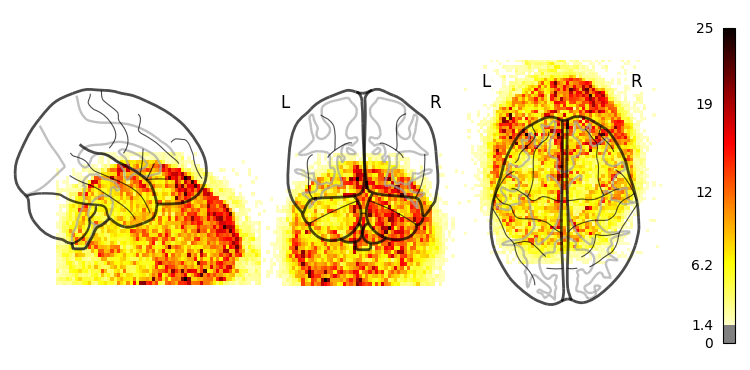

In [31]:
k = 0
component_map = A[:, k].reshape(X, Y, Z)
comp_img = nib.Nifti1Image(component_map, affine=img.affine)

plotting.plot_glass_brain(comp_img, display_mode="ortho")